In [ ]:
!pip install kagglehub[pandas-datasets]

In [ ]:
import kagglehub
kagglehub.login()

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "faviovaz/marketing-ab-testing",
    "marketing_AB.csv"
)

In [ ]:
df.head()

####**Check if we have duplicates with respect to user id**

In [ ]:
df.duplicated(subset='user id').sum()

In [ ]:
# Drop unwanted columns
df.drop(['Unnamed: 0', 'user id'], axis=1, inplace=True)

In [ ]:
df.columns

In [ ]:
df.info()

####**Check if the categorical variables have appropriate number of levels**

In [ ]:
df_cat = df[['test group', 'converted', 'most ads day', 'most ads hour']]

In [ ]:
df_cat.nunique()

In [ ]:
for i in df_cat.columns:
    print(i, "->", df_cat[i].unique())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

###**Univariate Analysis**

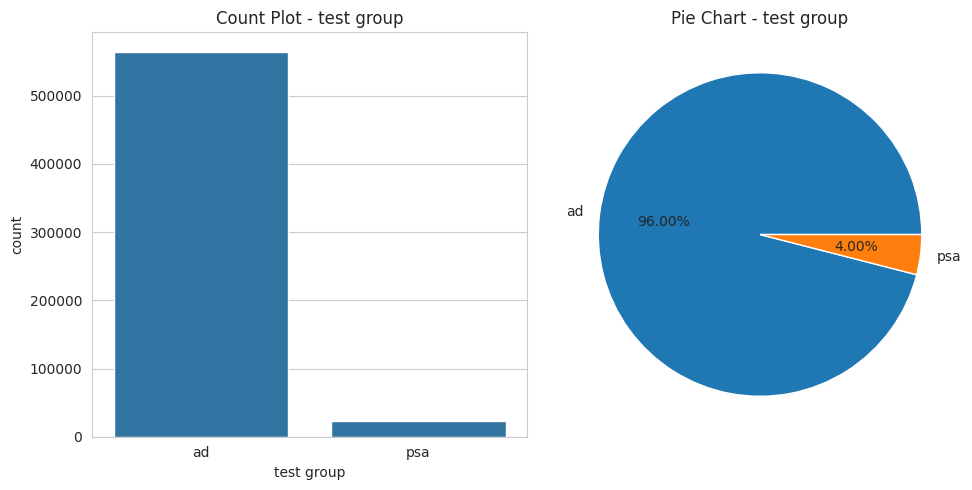

In [ ]:
variable = 'test group'

plt.figure(figsize = (10, 5))

# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x=variable, data=df_cat)
plt.title(f'Count Plot - {variable}')

# Pie chart
plt.subplot(1, 2, 2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

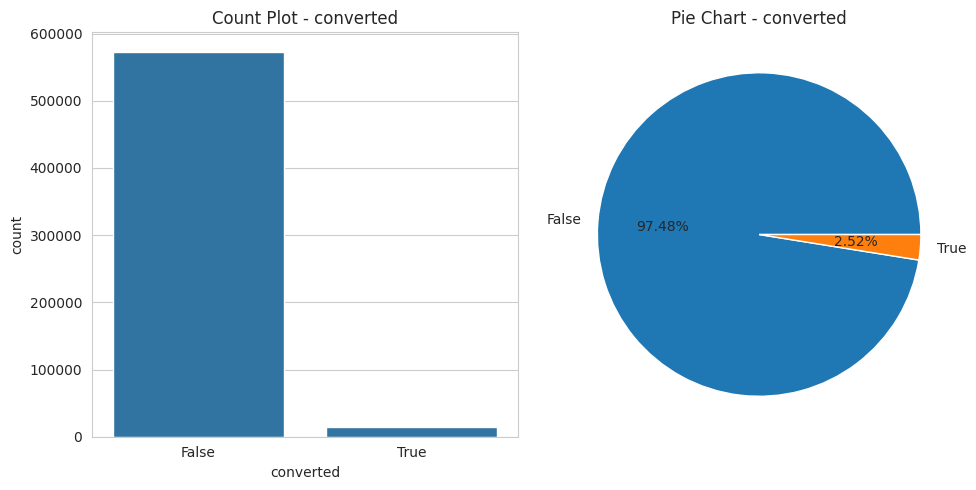

In [ ]:
variable = 'converted'

plt.figure(figsize = (10, 5))

# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x=variable, data=df_cat)
plt.title(f'Count Plot - {variable}')

# Pie chart
plt.subplot(1, 2, 2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

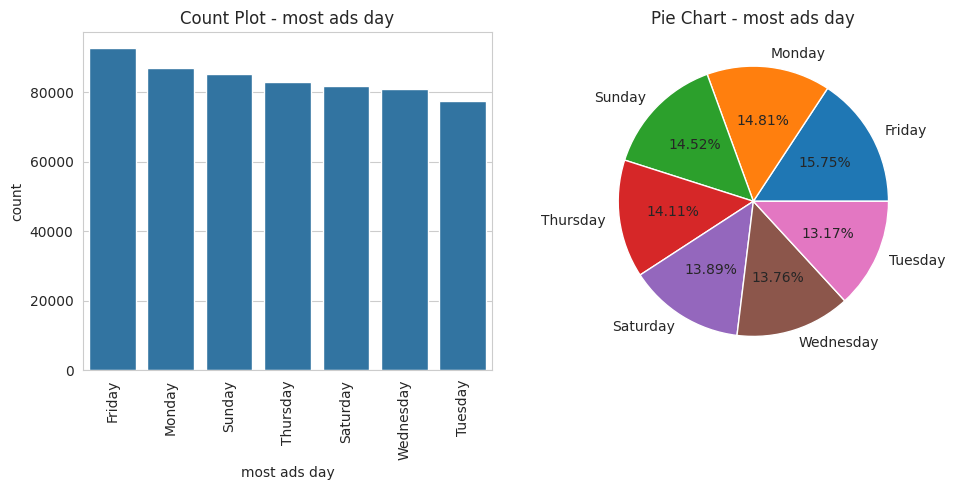

In [ ]:
variable = 'most ads day'

plt.figure(figsize = (10, 5))

# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x=variable, data=df_cat, order = df_cat['most ads day'].value_counts().index)
plt.title(f'Count Plot - {variable}')
plt.xticks(rotation = 90)

# Pie chart
plt.subplot(1, 2, 2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

In [ ]:
variable = 'most ads hour'

plt.figure(figsize = (15, 7))

# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x=variable, data=df_cat, order = df_cat['most ads hour'].value_counts().index)
plt.title(f'Count Plot - {variable}')
plt.xticks(rotation = 90)

# Pie chart
plt.subplot(1, 2, 2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

In [ ]:
variable = 'total ads'

plt.figure(figsize = (12, 4))
# Histogram
plt.subplot(1, 2, 1)
sns.histplot(x=variable, data=df)
plt.title(f'Histogram - {variable}')
# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y = variable, data = df)
plt.title(f'Boxplot - {variable}')
# Adjust layout
plt.tight_layout()
# Show the plots
plt.show()

In [ ]:
df['total ads'].describe()

,total ads
count,588101.000000
mean,24.820876
std,43.715181
min,1.000000
25%,4.000000
50%,13.000000
75%,27.000000
max,2065.000000


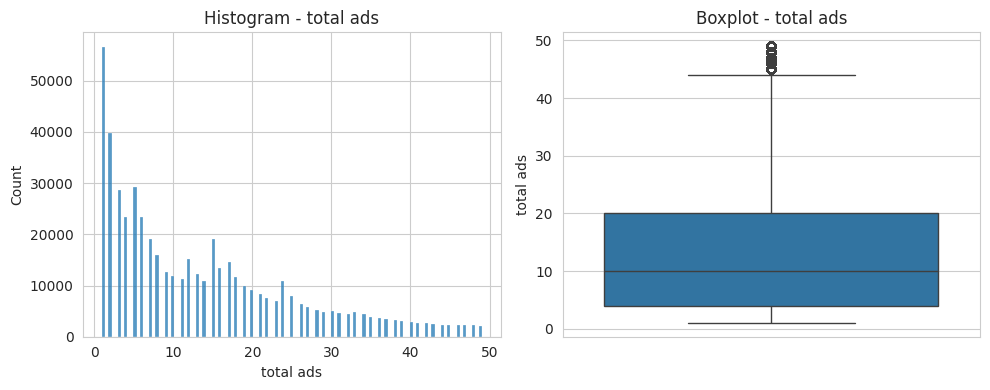

In [ ]:
variable = 'total ads'

plt.figure(figsize = (10, 4))

# Histogram
plt.subplot(1, 2, 1)
# Filtering the data for a value close to 75th percentile only for better visualization
sns.histplot(x=variable, data=df[df['total ads'] < 50])
plt.title(f'Histogram - {variable}')

# Boxplot (labeled as Pie chart in the original comment, but it's a Boxplot)
plt.subplot(1, 2, 2)
sns.boxplot(y = variable, data = df[df['total ads'] < 50])
plt.title(f'Boxplot - {variable}')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

###**Bivariate Analysis**

In [ ]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [ ]:
# Conversion by Test Group
ct_conversion_test_group = pd.crosstab(df['test group'], df['converted'], normalize = 'index')
ct_conversion_test_group

converted,False,True
test group,,
ad,0.974453,0.025547
psa,0.982146,0.017854


<Figure size 600x700 with 0 Axes>

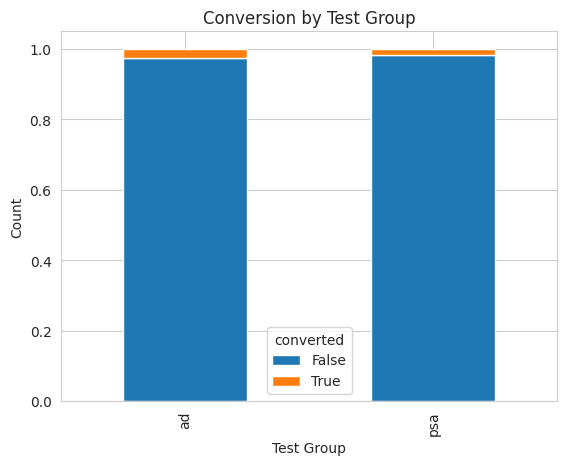

In [ ]:
plt.figure(figsize=(6, 7))

ct_conversion_test_group.plot.bar(stacked=True)
plt.title("Conversion by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Count")
plt.show()

In [ ]:
## conversion by day
ct_conversion_day = pd.crosstab(df['most ads day'], df['converted'], normalize = 'index')
print(ct_conversion_day.sort_values(by = True, ascending = False))

converted        False     True 
most ads day                    
Monday        0.967188  0.032812
Tuesday       0.970160  0.029840
Wednesday     0.975058  0.024942
Sunday        0.975524  0.024476
Friday        0.977788  0.022212
Thursday      0.978429  0.021571
Saturday      0.978949  0.021051


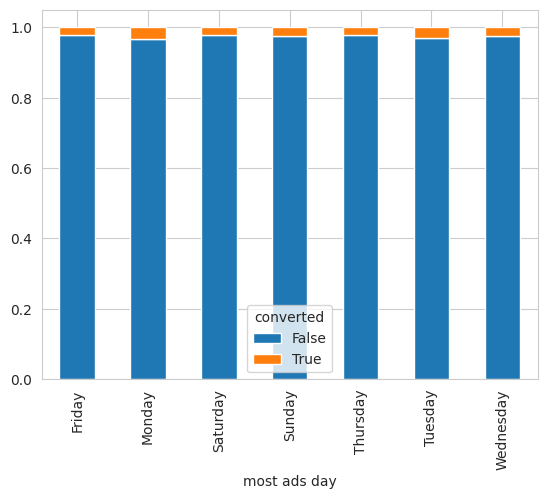

In [ ]:
ct_conversion_day.plot.bar(stacked = True);

### Conversion by Hour

In [ ]:
ct_conversion_hour = pd.crosstab(df['most ads hour'], df['converted'], normalize = 'index')
print(ct_conversion_hour.sort_values(by = True, ascending = False))


converted         False     True 
most ads hour                    
16             0.969228  0.030772
20             0.970197  0.029803
15             0.970347  0.029653
21             0.971077  0.028923
17             0.971790  0.028210
14             0.971937  0.028063
18             0.972620  0.027380
19             0.973280  0.026720
22             0.973895  0.026105
13             0.975323  0.024677
12             0.976172  0.023828
23             0.977338  0.022662
6              0.977756  0.022244
11             0.977884  0.022116
10             0.978479  0.021521
5              0.979085  0.020915
8              0.980484  0.019516
9              0.980809  0.019191
0              0.981575  0.018425
7              0.981889  0.018111
4              0.984765  0.015235
1              0.987089  0.012911
3              0.989548  0.010452
2              0.992687  0.007313


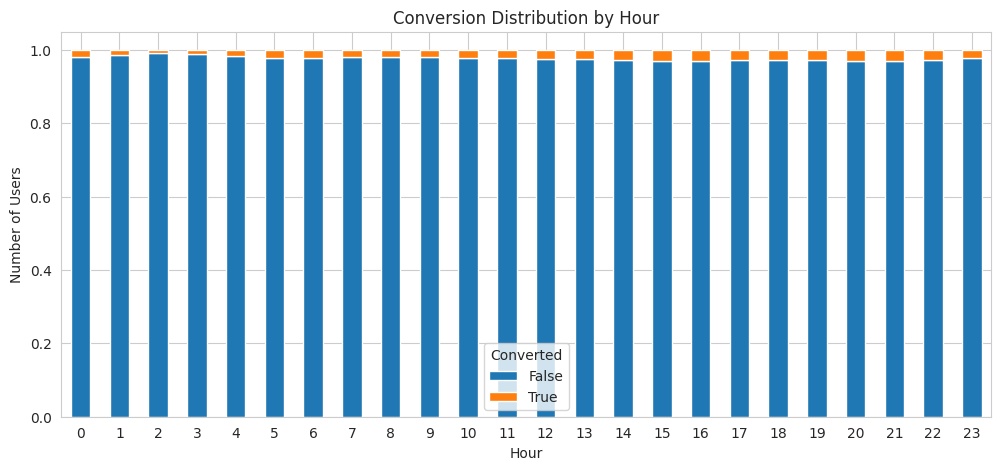

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ct_conversion_hour.plot.bar(
    stacked=True,
    ax=ax
)
ax.set_title("Conversion Distribution by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of Users")

plt.xticks(rotation=0)  # keep hours readable
plt.legend(title="Converted")
plt.show()

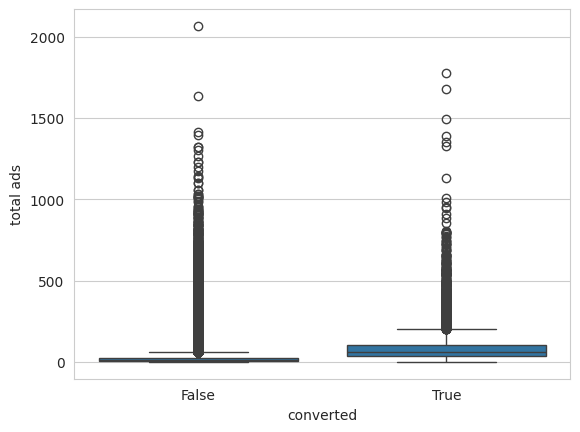

In [ ]:
# Comparing total ads seen by converted vs non-converted users
sns.boxplot(x = 'converted', y = 'total ads', data = df);

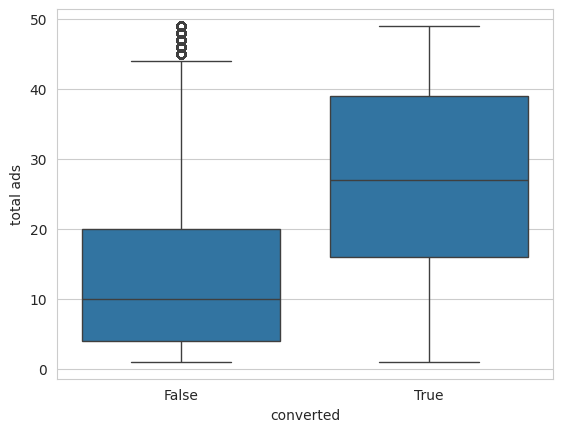

In [ ]:
# Same comparison but filtering out outliers for better visibility
sns.boxplot(x = 'converted', y = 'total ads', data = df[df['total ads'] < 50]);

- Users who converted generally saw more ads than users who did not convert. The median number of ads is significantly higher for converted users, indicating a positive relationship between ad exposure and conversion.

In [ ]:
df_cat.columns

Index(['test group', 'converted', 'most ads day', 'most ads hour'], dtype='object')

In [ ]:
from scipy.stats import chi2_contingency

##**Statistical Testing**

- use a Chi-squared test to prove whether the patterns that we saw in the charts are actually real (statistically significant) or just happened by pure chance.

In [ ]:
alpha = 0.05

for variable in df_cat.columns:
    if variable != 'converted':
        # Create a contingency table (cross-tabulation)
        contingency_table = pd.crosstab(df_cat[variable], df_cat['converted'])
        # Perform chi-squared test
        chi2, p, _, _ = chi2_contingency(contingency_table)
        # Display the results
        print(f"\nChi-squared test for {variable} vs. converted:")
        print(f"Chi-squared value: {chi2}")
        print(f"p-value: {p}")
        # Check for significance
        if p < alpha:
            print(f"The difference in conversion rates across {variable} is statistically significant.")
        else:
            print(f"There is no significant difference in conversion rates across {variable}.")


Chi-squared test for test group vs. converted:
Chi-squared value: 54.005823883685245
p-value: 1.9989623063390075e-13
The difference in conversion rates across test group is statistically significant.

Chi-squared test for most ads day vs. converted:
Chi-squared value: 410.0478857936585
p-value: 1.932184379244731e-85
The difference in conversion rates across most ads day is statistically significant.

Chi-squared test for most ads hour vs. converted:
Chi-squared value: 430.76869230822086
p-value: 8.027629823696771e-77
The difference in conversion rates across most ads hour is statistically significant.


# Statistical Test Interpretation

### Variable Breakdown

| Test Variable | Interpretation |
| :--- | :--- |
| **Test Group** | **The Ads Worked.** The difference between people who saw the real ad vs. the PSA (control) isn't a fluke. The ad campaign successfully influenced whether or not someone bought the product. |
| **Most Ads Day** | **Timing Matters (Weekly).** People are significantly more likely to convert on specific days of the week. We should prioritize budget for the "winning" days identified in the charts. |
| **Most Ads Hour** | **Timing Matters (Daily).** There are "high-conversion windows" during the day. This suggests that *when* we show the ad is just as important as *what* the ad says. |


In [ ]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu


In [ ]:
# Step 1: Check Assumptions
# Normality assumption
shapiro_stat_true, shapiro_p_value_true = shapiro(df[df['converted'] == True]['total ads'])
shapiro_stat_false, shapiro_p_value_false = shapiro(df[df['converted'] == False]['total ads'])

print(f"Shapiro-Wilk test for normality (True group): p-value = {shapiro_p_value_true}")
print(f"Shapiro-Wilk test for normality (False group): p-value = {shapiro_p_value_false}")

# Equality of variances assumption
levene_stat, levene_p_value = levene(df[df['converted'] == True]['total ads'], df[~df['converted']]['total ads'])
print(f"Levene's test for equality of variances: p-value = {levene_p_value}")

Shapiro-Wilk test for normality (True group): p-value = 1.638680987007771e-98
Shapiro-Wilk test for normality (False group): p-value = 9.883049430735801e-204
Levene's test for equality of variances: p-value = 0.0


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14843.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 573258.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# Step 2: Perform Suitable Test
alpha = 0.05

if shapiro_p_value_true > alpha and shapiro_p_value_false > alpha and levene_p_value > alpha:
    # Assumptions met - use t-test
    t_stat, t_p_value = ttest_ind(df[df['converted'] == True]['total ads'],
                                   df[df['converted'] == False]['total ads'])
    print(f"Independent two-sample t-test: p-value = {t_p_value}")
else:
    # Assumptions not met - use Mann-Whitney U test
    u_stat, u_p_value = mannwhitneyu(df[df['converted'] == True]['total ads'],
                                     df[df['converted'] == False]['total ads'])
    print(f"Mann-Whitney U test: p-value = {u_p_value}")

Mann-Whitney U test: p-value = 0.0
